In [1]:
import os
for k in ["http_proxy","https_proxy","all_proxy","HTTP_PROXY","HTTPS_PROXY","ALL_PROXY","NO_PROXY","no_proxy"]:
    os.environ.pop(k, None)
os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"

import torch
import numpy as np
from diffusers import StableDiffusionPipeline
import random
from tqdm import tqdm
import pandas as pd
import os
import argparse
# from clip_score_cal import CLIP_Score
import torch
from transformers import CLIPModel, CLIPProcessor
from PIL import Image
from functools import partial
import matplotlib.pyplot as plt
import uuid 
from torchvision.utils import make_grid
from torchvision import transforms

negative_prompt = "bad anatomy,watermark,extra digit,signature,worst quality,jpeg artifacts,normal quality,low quality,long neck,lowres,error,blurry,missing fingers,fewer digits,missing arms,text,cropped,Humpbacked ,bad hands,username"
MODEL_NAME="CompVis/stable-diffusion-v1-4"

In [2]:
# Some functions we need


def get_target_module(target_pipe, block='mid', layer_id=[0,0,0]):
    """
    get the target attention module in unet according to the block and layer_id.
    """
    block_id = layer_id[0]
    attn_id = layer_id[1]
    tsfm_id = layer_id[2]
    if block == 'mid':
        assert attn_id < 3 and tsfm_id < 1
        target_layer = target_pipe.unet.mid_block.attentions[attn_id].transformer_blocks[tsfm_id].attn2
    elif block == 'up':
        # unet.up_blocks[1:4] are CrossAttnUpBlock2D, which has XAttention
        assert 1< block_id < 4 and attn_id < 3 and tsfm_id < 1
        target_layer = target_pipe.unet.up_blocks[block_id].attentions[attn_id].transformer_blocks[tsfm_id].attn2
    elif block == 'down':
        # unet.down_blocks[0:4] are CrossAttnUpBlock2D, which has XAttention, but only has up to 2 attentions,
        # attn_id<=1
        assert block_id<4 and attn_id < 2 and tsfm_id < 1
        target_layer = target_pipe.unet.down_blocks[block_id].attentions[attn_id].transformer_blocks[tsfm_id].attn2
    else:
        raise KeyError
    return target_layer

@torch.no_grad()
def get_embedding(target_pipe, 
                  path_2_template, 
                  use_text_prompt=True,
                  path_2_ti=None,
                  ti_key='<style>',
                  concept='van gogh', 
                  rest_concepts=[],
                  postion = 'text_encoder',
                  block = 'mid',
                  layer_id=[0,0,0],
                  split_uncon=False,
                  num_prompt=1000):
    """
    get the embeddings at the target layer when the target concept is present or not. 
    If split_uncon is True, only the unconditional part of the embedding will be collected.
    """
    act={}
    rest_act = {}
    cnt = 0
    target_pipe.set_progress_bar_config(disable=True)
    if postion == 'text_encoder':
        target_module = target_pipe.text_encoder.encoder.layers[layer_id[0]].self_attn.out_proj
        hook_hanlder = target_module.register_forward_hook(
            partial(get_activation, 'target', act, split_uncon))
        
        with open(path_2_template, 'r') as file:
            templates = [line.strip() for line in file if line.strip()]
        templates = templates[:num_prompt]

        for line in templates:
            prompt = line.format(concept)
            text_inputs = target_pipe.tokenizer(
                prompt,
                max_length=target_pipe.tokenizer.model_max_length,
                truncation=True,
                return_tensors="pt",
            )
            prompt_embeds = target_pipe.text_encoder(
                text_inputs.input_ids.to(target_pipe.device),
                attention_mask=text_inputs.attention_mask.to(target_pipe.device),
            )[0][0]
  
        emb_lst = torch.cat(act['target'], dim=1).squeeze(0)
        act.clear()
        act = emb_lst

    elif postion == 'unet_self_attn':
        """
        unet has lots of blocks, each contains a attn2 module which does the cross attention 
        so we should choose only one block.
        """
        target_module = get_target_module(target_pipe, block, layer_id)
        hook_hanlder = target_module.to_v.register_forward_hook(
            partial(get_activation, 'target', act, split_uncon))
        with open(path_2_template, 'r') as file:
            templates = [line.strip() for line in file if line.strip()]
        templates = templates[:num_prompt]

        if use_text_prompt:    
            for line in templates:
                prompt = line.format(concept)
                res = target_pipe(prompt,
                            negative_prompt=None,
                            # generator=torch.manual_seed(2025),
                            num_inference_steps=1,
                            )[0]
        if isinstance(path_2_ti, list):
            for p2ti in path_2_ti:
                if os.path.exists(p2ti):
                    target_pipe.load_textual_inversion(str(p2ti))
                    for line in templates:
                        prompt = line.format(ti_key)
                        res = target_pipe(prompt,
                                    negative_prompt=None,
                                    generator=torch.manual_seed(2025),
                                    num_inference_steps=1,
                                    )[0]
        hook_hanlder.remove()

        for rest_c in rest_concepts:
            hook_hanlder = target_module.to_v.register_forward_hook(
            partial(get_activation, 'rest', rest_act, split_uncon))
            with open(path_2_template, 'r') as file:
                for line in file:
                    prompt = line.format(concept)
                    res = target_pipe(prompt,
                                negative_prompt=None,
                                generator=torch.manual_seed(2025),
                                num_inference_steps=1,
                                )[0]
    return act, rest_act

def get_activation(layer_name, act, split_uncon, layer, inp, out):
    if layer_name in act.keys():
        if split_uncon:
            size = inp[0].shape[0]
            act[layer_name].append(inp[0][size//2:].cpu().detach())
        else:
            act[layer_name].append(inp[0].cpu().detach())
    else:
        if split_uncon:
            size = inp[0].shape[0]
            act[layer_name] = [inp[0][size//2:].cpu().detach()]
        else:
            act[layer_name] = [inp[0].cpu().detach()]

class PipeWithHookerForPromptEmbed(StableDiffusionPipeline):
    """
    a customized pipeline that returns the prompt embedding .
    """
    @torch.no_grad()
    def encode_prompt(
        self,
        prompt,
        device,
        num_images_per_prompt=1,
        do_classifier_free_guidance=False,
        negative_prompt=None,
        prompt_embeds=None,
        negative_prompt_embeds=None,
        lora_scale=None,
        clip_skip=None,
        **kwargs,
    ):
        # 1) 自己 tokenize 一次，拿到 attention_mask（只针对 positive）
        text_inputs = self.tokenizer(
            prompt if isinstance(prompt, list) else [prompt],
            padding="max_length",
            max_length=self.tokenizer.model_max_length,
            truncation=True,
            return_tensors="pt",
        )
        pos_attention_mask = text_inputs.attention_mask.to(device)  # [B,77]
        
        # 2) 走原版 encode_prompt 得到 prompt_embeds / negative_prompt_embeds
        prompt_embeds, negative_prompt_embeds = super().encode_prompt(
            prompt=prompt,
            device=device,
            num_images_per_prompt=num_images_per_prompt,
            do_classifier_free_guidance=do_classifier_free_guidance,
            negative_prompt=negative_prompt,
            prompt_embeds=prompt_embeds,
            negative_prompt_embeds=negative_prompt_embeds,
            lora_scale=lora_scale,
            clip_skip=clip_skip,
            **kwargs,
        )

        # --- remove pad tokens (ONLY for analysis, not modifying embeds yet) ---
        mask = pos_attention_mask.bool()
        valid_hidden = torch.cat(
            [prompt_embeds[i][mask[i]] for i in range(prompt_embeds.shape[0])],
            dim=0,
        )

        # --- cache for external use ---
        self._last_valid_hidden = valid_hidden.detach().float().cpu()
        self._last_attention_mask = pos_attention_mask.detach().cpu()

        return prompt_embeds, negative_prompt_embeds

def help_embedding(args):
    pipe_hooker = PipeWithHookerForPromptEmbed.from_pretrained(MODEL_NAME,
                                        torch_dtype=torch.float16,
                                        safety_checker = None).to(device)
    collect_embedding, resc_embedding =get_embedding(pipe_hooker,
                                                    args.path_2_prompt_template, 
                                                    use_text_prompt=True,
                                                    concept=args.target_concept, 
                                                    rest_concepts=['cat'],
                                                    postion=args.proj_position,
                                                    block=args.block,
                                                    layer_id=args.layer_id,
                                                    split_uncon=args.split_uncon,
                                                    num_prompt=args.num_prompt_pre)
    del pipe_hooker
    return collect_embedding


def project_text_conder_attn(pipe, proj_matrix, layer_id=11):
    target_layer = pipe.text_encoder.encoder.layers[layer_id].self_attn.out_proj
    org_weight = target_layer.weight.data.clone()
    target_layer.weight.data = torch.matmul(
        org_weight, proj_matrix.to(org_weight.device).to(org_weight.dtype))


def get_basis(emebd, rank=1):
    X = emebd.reshape(-1, 768).to(torch.float32)
    # X = X - X.mean(dim=0, keepdim=True)
    U, S, V = torch.svd(X.T)
    if isinstance(rank, list):
        subspace = torch.matmul(U[:, rank[0]:rank[1]], U[:, rank[0]:rank[1]].T)
    else:
        subspace = torch.matmul(U[:, :rank], U[:, :rank].T)
    return subspace, S

def get_proj(emebd, rank=1, lam=1, plot=False):
    subspace, S = get_basis(emebd, rank=rank)
    proj = torch.eye(subspace.shape[0])-lam*subspace
    if plot:
        return proj, S
    else:
        return proj
      
def plot_exp_var(S, rank=40):
    rank = min(rank, S.shape[0])
    plt.figure(figsize=(4, 4), dpi=100)
    colors = ['tab:red'] + ['gray'] * (rank - 1)
    hatches = ['//'] + ['.'] * (rank - 1)  # Add stripes only to the first bar
    # Plot the bars with specified colors
    bars = plt.bar(np.arange(1, rank + 1), height=(S**2 / (S**2).sum())[:rank], color=colors)
    # Apply hatching
    for bar, hatch in zip(bars, hatches):
        bar.set_hatch(hatch)
    plt.grid()
    plt.ylabel('Explained variance ratio')
    plt.yscale('log')


@torch.no_grad()
def generate_img(
    pipe,
    prompt,
    num_img=12,
    negative_prompt=None,
    seed=None,
    num_inference_steps=50
):
    res = []

    try:
        pipe.set_progress_bar_config(disable=True)
    except:
        pass

    for i in range(num_img):
        if seed is not None:
            g = torch.Generator(
                device=pipe.unet.device
            ).manual_seed(seed + i * 100)

            latents = torch.randn(
                (1, pipe.unet.config.in_channels, 64, 64),
                generator=g,
                device=pipe.unet.device,
                dtype=pipe.unet.dtype,
            )

            image = pipe(
                prompt=prompt,
                latents=latents,
                negative_prompt=negative_prompt,
                num_inference_steps=num_inference_steps,
            )[0]

        else:
            image = pipe(
                prompt=prompt,
                negative_prompt=negative_prompt,
                num_inference_steps=num_inference_steps,
            )[0]

        res.append(image)

    return [x[0] for x in res]
def showimages(images, 
                prompt=None, 
                max_per_row = 6, 
                transpose=False, 
                save_dir='temp_folder',
                prefix=None,
                padding=0,
                save=True,
                show_dpi=20,
                save_dpi=300):
    os.makedirs(save_dir, exist_ok=True)
    # Define transform to convert PIL images to tensors
    to_tensor = transforms.ToTensor()
    
    if transpose:
        temp_images = []
        for j in range(max_per_row):
            for i in range(j, len(images), max_per_row):
                temp_images.extend([images[i]])
        images = temp_images

    # Convert each image to a PyTorch tensor
    images_tensor = torch.stack([to_tensor(image) for image in images])

    if transpose:
        grid = make_grid(images_tensor, nrow=len(images)//max_per_row, padding=10, pad_value=1)
    else:
        grid = make_grid(images_tensor, nrow=max_per_row, padding=10, pad_value=1)

    # Convert the grid to numpy format for displaying with matplotlib
    grid_np = grid.permute(1, 2, 0).numpy()
    if transpose:
        plt.figure(figsize=((len(images) // max_per_row + 1) * 1, max_per_row * 1), dpi=show_dpi)
    else:   
        plt.figure(figsize=(max_per_row * 1, (len(images) // max_per_row + 1) * 1), dpi=show_dpi)
    plt.imshow(grid_np)
    plt.axis("off")
    if prompt:
        plt.title(prompt, fontsize=15)
    plt.tight_layout(pad=-50)
    plt.show()
    plt.close()

    if transpose:
        plt.figure(figsize=((len(images) // max_per_row + 1) * 2, max_per_row * 2), dpi=save_dpi)
    else:   
        plt.figure(figsize=(max_per_row * 2, (len(images) // max_per_row + 1) * 2), dpi=save_dpi)
    if save:
        plt.imshow(grid_np)
        plt.axis("off")
        plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
        fig_name = str(uuid.uuid1())
        if prefix:
            fig_name = prefix + fig_name
        plt.savefig(f"{save_dir}/{fig_name}.png", bbox_inches='tight')
        torch.save(images, f"{save_dir}/{fig_name}.pth")
        print(f"save pdf {save_dir}/{fig_name}.png, raw data at {save_dir}/{fig_name}.pth")
        plt.close()

        
# If you want to detect the present rate of target concpet presented 
# in the generated images, you can use the following code:
device = torch.device("cuda") 
model_id = "openai/clip-vit-large-patch14"
model = CLIPModel.from_pretrained(model_id).to(device).eval()
processor = CLIPProcessor.from_pretrained(model_id)

@torch.inference_mode()
def clip_score(model, processor, device, imgs, prompt):
    # images = [Image.open(p).convert("RGB") for p in imgs]
    inputs = processor(
        text=prompt,
        images=imgs,
        return_tensors="pt",
        padding=True,
    ).to(device)

    num_car = 0
    total = 0
    
    # logits_per_image: [B, 2] (image-to-text similarity, already scaled)
    outputs = model(**inputs)
    logits = outputs.logits_per_image  # [B, 2]

    pred = logits.argmax(dim=1)  # 0 => car, 1 => without car
    num_car += (pred == 0).sum().item()
    total += logits.size(0)
    return {"total": total, "num_car": num_car, "car_ratio": num_car / max(total, 1)}

CAR_PROMPTS = [
    'a photo of a car'
]

@torch.inference_mode()
def clip_car_scores(model, processor, device, imgs, prompt):
    text_inputs = processor(
        text=prompt,
        return_tensors="pt",
        padding=True
    ).to(device)

    text_features = model.get_text_features(**text_inputs)

    # compatibility with newer transformers
    if hasattr(text_features, "pooler_output"):
        text_features = text_features.pooler_output

    text_features = text_features / text_features.norm(
        dim=-1,
        keepdim=True
    )

    image_inputs = processor(
        images=imgs,
        return_tensors="pt"
    ).to(device)

    image_features = model.get_image_features(**image_inputs)

    # compatibility with newer transformers
    if hasattr(image_features, "pooler_output"):
        image_features = image_features.pooler_output

    image_features = image_features / image_features.norm(
        dim=-1,
        keepdim=True
    )

    sim = image_features @ text_features.T

    return sim.mean(dim=1).cpu()

def car_detection_rate(scores, threshold):
    return (scores > threshold).float().mean().item()


Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

In [5]:
arg = argparse.ArgumentParser()
arg.add_argument('--proj_position', type=str, default='text_encoder', 
                 help='the position to project, choose from [unet_self_attn, text_encoder]')
arg.add_argument('--target_concept', type=str, default='car',)
arg.add_argument('--num_img', type=int, default=10,)
arg.add_argument('--num_prompt_pre', type=int, default=1,)
arg.add_argument('--num_prompt_gen', type=int, default=30,)
arg.add_argument('--seed', type=int, default=2025,)
arg.add_argument('--path_2_prompt_template', type=str, default='./1000_short_t2i_prompts.txt',)
arg.add_argument('--num_rest_concepts', type=int, default=4,)
arg.add_argument('--model_name', type=str, default='CompVis/stable-diffusion-v1-4',)
arg.add_argument('--test_run', action='store_true', 
                 help='whether to do a test run with reduced settings')
arg.add_argument('--save_path', type=str, default='tdsc_rebuttal_results_adavd_template2')
arg.add_argument('--block', type=str, default='mid')
arg.add_argument('--layer_id', type=list, default=[0, 0, 0])
arg.add_argument('--split_uncon', type=bool, default=False)

device = torch.device("cuda") 

DEFAULT_REST_CONCEPT_POOL = [
    "Vincent van Gogh",
    "Pablo Picasso",
    "Claude Monet",
    "Andy Warhol",
    "Amerighi da Caravaggio"
]

args = arg.parse_args([])

args.num_prompt_pre = 20
args.path_2_prompt_template = '../1000_short_t2i_prompts.txt'



# Erase Taylor Swift

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class '__main__.PipeWithHookerForPromptEmbed'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


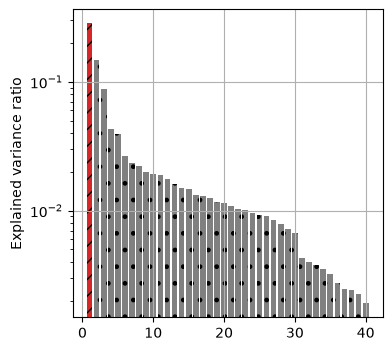

In [7]:
args.target_concept = 'Taylor Swift'

proj_pipe = StableDiffusionPipeline.from_pretrained(MODEL_NAME,
                                                    torch_dtype=torch.float16,
                                                    safety_checker = None,).to(device)

collect_embedding = help_embedding(args)

U, S, V = torch.svd(collect_embedding.reshape(-1, 768).cpu().to(torch.float32).T)


proj_matrix = torch.eye(U.shape[0])-4*torch.matmul(U[:, :1], U[:, :1].T)

project_text_conder_attn(proj_pipe, proj_matrix, layer_id=0)

plot_exp_var(S)

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


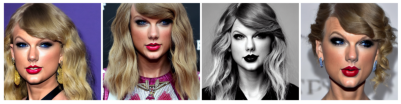

save pdf temp_folder/1f185fe0-a96e-11f1-ac42-eeaab3fc1772.png, raw data at temp_folder/1f185fe0-a96e-11f1-ac42-eeaab3fc1772.pth


AttributeError: 'BaseModelOutputWithPooling' object has no attribute 'norm'

In [5]:
prompt = f"a portrait of {args.target_concept}"

sd_pipe = StableDiffusionPipeline.from_pretrained(MODEL_NAME,
                                                    torch_dtype=torch.float16,
                                                    safety_checker = None,).to(device)

before_image = generate_img(sd_pipe, 
                    prompt, 
                    num_img=4, 
                    negative_prompt=negative_prompt,
                    seed=2025
                    )
showimages(before_image) 
before_score = clip_car_scores(model, processor, device, before_image, 'a photo of a Taylor Swift')
threshold = before_score.mean()
threshold, before_score

In [7]:
before_score = clip_car_scores(
    model,
    processor,
    device,
    before_image,
    'a photo of Taylor Swift'
)

threshold = before_score.mean()

print("Before scores:", before_score)
print("Mean:", threshold)

Before scores: tensor([0.2404, 0.2425, 0.2548, 0.2664])
Mean: tensor(0.2510)


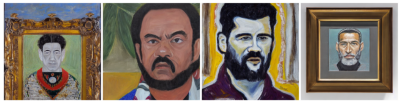

save pdf temp_folder/ba63ea26-a970-11f1-ac42-eeaab3fc1772.png, raw data at temp_folder/ba63ea26-a970-11f1-ac42-eeaab3fc1772.pth


In [8]:
after_image = generate_img(
    proj_pipe,
    prompt,
    num_img=4,
    negative_prompt=negative_prompt,
    seed=2025
)

showimages(after_image)

In [8]:
variance = S ** 2
explained_variance_ratio = variance / variance.sum()
cumulative_variance = torch.cumsum(explained_variance_ratio, dim=0)

print("Top 10 singular values:")
print(S[:10])

print("\nTop 10 explained variance ratios:")
print(explained_variance_ratio[:10])

print("\nTop 10 cumulative explained variance:")
print(cumulative_variance[:10])

Top 10 singular values:
tensor([67.8507, 48.9006, 37.5749, 26.3643, 25.2788, 20.7696, 19.5390, 19.0243,
        17.9038, 17.5795])

Top 10 explained variance ratios:
tensor([0.2848, 0.1479, 0.0873, 0.0430, 0.0395, 0.0267, 0.0236, 0.0224, 0.0198,
        0.0191])

Top 10 cumulative explained variance:
tensor([0.2848, 0.4327, 0.5200, 0.5630, 0.6026, 0.6293, 0.6529, 0.6753, 0.6951,
        0.7142])


In [9]:
thresholds = [0.70, 0.80, 0.90, 0.95]

for threshold in thresholds:
    rank = int(
        torch.searchsorted(
            cumulative_variance,
            torch.tensor(threshold)
        ).item()
    ) + 1

    print(
        f"Threshold {threshold:.0%} -> "
        f"rank = {rank}, "
        f"cumulative variance = {cumulative_variance[rank-1]:.4f}"
    )

Threshold 70% -> rank = 10, cumulative variance = 0.7142
Threshold 80% -> rank = 16, cumulative variance = 0.8094
Threshold 90% -> rank = 25, cumulative variance = 0.9079
Threshold 95% -> rank = 31, cumulative variance = 0.9517


In [10]:
# Pilot experiment: fixed rank = 2

test_rank = 2

rank2_pipe = StableDiffusionPipeline.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    safety_checker=None,
).to(device)

U_r = U[:, :test_rank]

rank2_proj_matrix = (
    torch.eye(U.shape[0])
    - 4 * torch.matmul(U_r, U_r.T)
)

project_text_conder_attn(
    rank2_pipe,
    rank2_proj_matrix,
    layer_id=0
)

print(f"Rank {test_rank} projection applied successfully.")

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


Rank 2 projection applied successfully.


In [12]:
prompt = f"a portrait of {args.target_concept}"

print(prompt)

a portrait of Taylor Swift


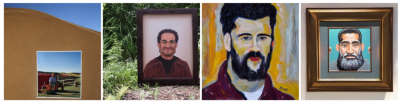

save pdf temp_folder/0668f09a-b79c-11f1-b7cb-c20abd0a5b2d.png, raw data at temp_folder/0668f09a-b79c-11f1-b7cb-c20abd0a5b2d.pth


In [13]:
rank2_images = generate_img(
    rank2_pipe,
    prompt,
    num_img=4,
    negative_prompt=negative_prompt,
    seed=2025
)

showimages(rank2_images)

In [14]:
rank2_score = clip_car_scores(
    model,
    processor,
    device,
    rank2_images,
    "a photo of Taylor Swift"
)

print("Rank 2 scores:", rank2_score)
print("Rank 2 mean:", rank2_score.mean().item())

Rank 2 scores: tensor([0.1564, 0.1187, 0.1607, 0.1385])
Rank 2 mean: 0.14355531334877014


In [15]:
# Controlled experiment: fixed rank = 1

test_rank = 1

rank1_pipe = StableDiffusionPipeline.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    safety_checker=None,
).to(device)

U_r = U[:, :test_rank]

rank1_proj_matrix = (
    torch.eye(U.shape[0])
    - 4 * torch.matmul(U_r, U_r.T)
)

project_text_conder_attn(
    rank1_pipe,
    rank1_proj_matrix,
    layer_id=0
)

print(f"Rank {test_rank} projection applied successfully.")

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


Rank 1 projection applied successfully.


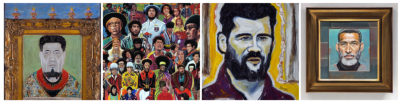

save pdf temp_folder/c01105e4-b7b7-11f1-b7cb-c20abd0a5b2d.png, raw data at temp_folder/c01105e4-b7b7-11f1-b7cb-c20abd0a5b2d.pth


In [17]:
rank1_images = generate_img(
    rank1_pipe,
    prompt,
    num_img=4,
    negative_prompt=negative_prompt,
    seed=2025
)

showimages(rank1_images)

In [18]:
rank1_score = clip_car_scores(
    model,
    processor,
    device,
    rank1_images,
    "a photo of Taylor Swift"
)

print("Rank 1 scores:", rank1_score)
print("Rank 1 mean:", rank1_score.mean().item())

print("\nRank 2 scores:", rank2_score)
print("Rank 2 mean:", rank2_score.mean().item())

Rank 1 scores: tensor([0.1523, 0.1140, 0.1228, 0.1472])
Rank 1 mean: 0.13407458364963531

Rank 2 scores: tensor([0.1564, 0.1187, 0.1607, 0.1385])
Rank 2 mean: 0.14355531334877014


In [20]:
import gc

try:
    del rank1_pipe
except:
    pass

try:
    del rank2_pipe
except:
    pass

gc.collect()
torch.cuda.empty_cache()

print(
    f"GPU allocated: "
    f"{torch.cuda.memory_allocated() / 1024**3:.2f} GB"
)

GPU allocated: 3.62 GB


In [8]:
import gc
import torch
from diffusers import StableDiffusionPipeline

def run_single_rank(
    rank,
    U_concept,
    prompt,
    clip_prompt,
    seed=2025,
    num_inference_steps=15,
    lambda_value=4,
    layer_id=0
):
    pipe = StableDiffusionPipeline.from_pretrained(
        MODEL_NAME,
        torch_dtype=torch.float16,
        safety_checker=None,
    ).to(device)

    U_r = U_concept[:, :rank]

    proj_matrix = (
        torch.eye(U_concept.shape[0])
        - lambda_value * torch.matmul(U_r, U_r.T)
    )

    project_text_conder_attn(
        pipe,
        proj_matrix,
        layer_id=layer_id
    )

    images = generate_img(
        pipe,
        prompt,
        num_img=1,
        negative_prompt=negative_prompt,
        seed=seed,
        num_inference_steps=num_inference_steps
    )

    scores = clip_car_scores(
        model,
        processor,
        device,
        images,
        clip_prompt
    )

    result = {
        "rank": rank,
        "score": scores.mean().item(),
        "image": images[0]
    }

    del pipe
    gc.collect()
    torch.cuda.empty_cache()

    return result

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


1
0.11413182318210602


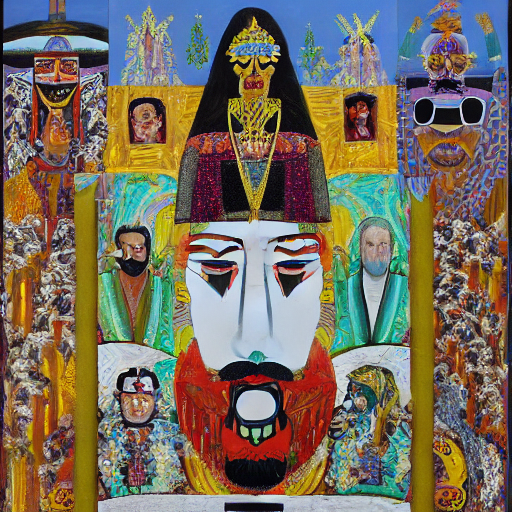

In [23]:
test_result = run_single_rank(
    rank=1,
    prompt="a portrait of Taylor Swift",
    clip_prompt="a photo of Taylor Swift",
    seed=2025,
    num_inference_steps=15
)

print(test_result["rank"])
print(test_result["score"])

display(test_result["image"])

In [24]:
ranks = [1, 2, 4, 8, 10, 16]

sweep_results = []

for rank in ranks:
    print(f"\nRunning rank = {rank}...")

    result = run_single_rank(
        rank=rank,
        prompt="a portrait of Taylor Swift",
        clip_prompt="a photo of Taylor Swift",
        seed=2025,
        num_inference_steps=15
    )

    sweep_results.append(result)

    print(
        f"rank={rank}, "
        f"CLIP score={result['score']:.6f}"
    )


Running rank = 1...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


rank=1, CLIP score=0.114132

Running rank = 2...


...

rank=10, CLIP score=0.190509

Running rank = 16...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


rank=16, CLIP score=0.169471


In [25]:
# ===== Van Gogh concept analysis =====

args.target_concept = "Vincent van Gogh"

van_gogh_embedding = help_embedding(args)

U_vg, S_vg, V_vg = torch.svd(
    van_gogh_embedding
    .reshape(-1, 768)
    .cpu()
    .to(torch.float32)
    .T
)

vg_variance = S_vg ** 2
vg_ratio = vg_variance / vg_variance.sum()
vg_cumulative = torch.cumsum(vg_ratio, dim=0)

print("Van Gogh - Top 10 singular values:")
print(S_vg[:10])

print("\nVan Gogh - Top 10 explained variance ratios:")
print(vg_ratio[:10])

print("\nVan Gogh - Top 10 cumulative explained variance:")
print(vg_cumulative[:10])

for threshold in [0.70, 0.80, 0.90, 0.95]:
    rank = int(
        torch.searchsorted(
            vg_cumulative,
            torch.tensor(threshold)
        ).item()
    ) + 1

    print(
        f"Threshold {threshold:.0%} -> "
        f"rank={rank}, "
        f"cumulative={vg_cumulative[rank-1]:.4f}"
    )

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class '__main__.PipeWithHookerForPromptEmbed'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


Van Gogh - Top 10 singular values:
tensor([75.9907, 56.2038, 43.1580, 37.8450, 28.2158, 25.1015, 21.0311, 19.5636,
        19.0375, 17.9317])

Van Gogh - Top 10 explained variance ratios:
tensor([0.2872, 0.1571, 0.0926, 0.0712, 0.0396, 0.0313, 0.0220, 0.0190, 0.0180,
        0.0160])

Van Gogh - Top 10 cumulative explained variance:
tensor([0.2872, 0.4442, 0.5369, 0.6081, 0.6477, 0.6790, 0.7010, 0.7201, 0.7381,
        0.7541])
Threshold 70% -> rank=7, cumulative=0.7010
Threshold 80% -> rank=14, cumulative=0.8123
Threshold 90% -> rank=23, cumulative=0.9029
Threshold 95% -> rank=30, cumulative=0.9526


In [27]:
vg_ranks = [1, 2, 4, 7, 8, 14]

vg_results = []

for rank in vg_ranks:
    print(f"\nRunning Van Gogh rank = {rank}...")

    result = run_single_rank(
        rank=rank,
        U_concept=U_vg,
        prompt="a painting in the style of Vincent van Gogh",
        clip_prompt="a painting in the style of Vincent van Gogh",
        seed=2025,
        num_inference_steps=15
    )

    vg_results.append(result)

    print(
        f"rank={rank}, "
        f"CLIP score={result['score']:.6f}"
    )


Running Van Gogh rank = 1...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


rank=1, CLIP score=0.182230

Running Van Gogh rank = 2...


...

rank=8, CLIP score=0.124851

Running Van Gogh rank = 14...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


rank=14, CLIP score=0.201830


In [28]:
vg_test_ranks = [1, 4, 7]
vg_test_seeds = [2025, 2026, 2027]

vg_stability_results = []

for rank in vg_test_ranks:
    for seed in vg_test_seeds:
        print(f"\nRunning Van Gogh rank={rank}, seed={seed}...")

        result = run_single_rank(
            rank=rank,
            U_concept=U_vg,
            prompt="a painting in the style of Vincent van Gogh",
            clip_prompt="a painting in the style of Vincent van Gogh",
            seed=seed,
            num_inference_steps=15
        )

        vg_stability_results.append({
            "rank": rank,
            "seed": seed,
            "score": result["score"]
        })

        print(
            f"rank={rank}, seed={seed}, "
            f"CLIP={result['score']:.6f}"
        )


Running Van Gogh rank=1, seed=2025...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


rank=1, seed=2025, CLIP=0.182230

Running Van Gogh rank=1, seed=2026...


...

rank=7, seed=2026, CLIP=0.168622

Running Van Gogh rank=7, seed=2027...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


rank=7, seed=2027, CLIP=0.127651


In [29]:
import pandas as pd

df_vg = pd.DataFrame(vg_stability_results)

summary_vg = (
    df_vg
    .groupby("rank")["score"]
    .agg(["mean", "std", "min", "max"])
    .reset_index()
)

print(df_vg)
print("\nSummary:")
print(summary_vg)


   rank  seed     score
0     1  2025  0.182230
1     1  2026  0.161023
2     1  2027  0.182763
3     4  2025  0.084104
4     4  2026  0.130923
5     4  2027  0.130695
6     7  2025  0.101970
7     7  2026  0.168622
8     7  2027  0.127651

Summary:
   rank      mean       std       min       max
0     1  0.175338  0.012401  0.161023  0.182763
1     4  0.115241  0.026965  0.084104  0.130923
2     7  0.132748  0.033617  0.101970  0.168622


In [30]:
# ===== Car concept analysis =====

args.target_concept = "car"

car_embedding = help_embedding(args)

U_car, S_car, V_car = torch.svd(
    car_embedding
    .reshape(-1, 768)
    .cpu()
    .to(torch.float32)
    .T
)

car_variance = S_car ** 2
car_ratio = car_variance / car_variance.sum()
car_cumulative = torch.cumsum(car_ratio, dim=0)

print("Car - Top 10 singular values:")
print(S_car[:10])

print("\nCar - Top 10 explained variance ratios:")
print(car_ratio[:10])

print("\nCar - Top 10 cumulative explained variance:")
print(car_cumulative[:10])

for threshold in [0.70, 0.80, 0.90, 0.95]:
    rank = int(
        torch.searchsorted(
            car_cumulative,
            torch.tensor(threshold)
        ).item()
    ) + 1

    print(
        f"Threshold {threshold:.0%} -> "
        f"rank={rank}, "
        f"cumulative={car_cumulative[rank-1]:.4f}"
    )

/opt/conda/lib/python3.11/site-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class '__main__.PipeWithHookerForPromptEmbed'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


Car - Top 10 singular values:
tensor([45.6319, 35.3673, 26.8936, 25.7577, 20.0013, 19.4265, 19.0896, 17.9217,
        17.7470, 17.5745])

Car - Top 10 explained variance ratios:
tensor([0.1858, 0.1116, 0.0645, 0.0592, 0.0357, 0.0337, 0.0325, 0.0287, 0.0281,
        0.0276])

Car - Top 10 cumulative explained variance:
tensor([0.1858, 0.2974, 0.3619, 0.4211, 0.4568, 0.4905, 0.5230, 0.5516, 0.5798,
        0.6073])
Threshold 70% -> rank=15, cumulative=0.7199
Threshold 80% -> rank=20, cumulative=0.8070
Threshold 90% -> rank=27, cumulative=0.9017
Threshold 95% -> rank=35, cumulative=0.9532


In [31]:
car_ranks = [1, 2, 4, 8]

car_results = []

for rank in car_ranks:
    print(f"\nRunning Car rank = {rank}...")

    result = run_single_rank(
        rank=rank,
        U_concept=U_car,
        prompt="a photo of a car",
        clip_prompt="a photo of a car",
        seed=2025,
        num_inference_steps=15
    )

    car_results.append(result)

    print(
        f"rank={rank}, "
        f"CLIP score={result['score']:.6f}"
    )


Running Car rank = 1...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


rank=1, CLIP score=0.209231

Running Car rank = 2...


...

rank=4, CLIP score=0.167254

Running Car rank = 8...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


rank=8, CLIP score=0.173842


In [32]:
car_test_ranks = [1, 2, 4]
car_test_seeds = [2025, 2026, 2027]

car_stability_results = []

for rank in car_test_ranks:
    for seed in car_test_seeds:
        print(f"\nRunning Car rank={rank}, seed={seed}...")

        result = run_single_rank(
            rank=rank,
            U_concept=U_car,
            prompt="a photo of a car",
            clip_prompt="a photo of a car",
            seed=seed,
            num_inference_steps=15
        )

        car_stability_results.append({
            "rank": rank,
            "seed": seed,
            "score": result["score"]
        })

        print(
            f"rank={rank}, seed={seed}, "
            f"CLIP={result['score']:.6f}"
        )


Running Car rank=1, seed=2025...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


rank=1, seed=2025, CLIP=0.209231

Running Car rank=1, seed=2026...


...

rank=4, seed=2026, CLIP=0.112455

Running Car rank=4, seed=2027...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


rank=4, seed=2027, CLIP=0.145387


In [33]:
df_car = pd.DataFrame(car_stability_results)

summary_car = (
    df_car
    .groupby("rank")["score"]
    .agg(["mean", "std", "min", "max"])
    .reset_index()
)

print(df_car)
print("\nSummary:")
print(summary_car)

   rank  seed     score
0     1  2025  0.209231
1     1  2026  0.121951
2     1  2027  0.101760
3     2  2025  0.127452
4     2  2026  0.122607
5     2  2027  0.101984
6     4  2025  0.167254
7     4  2026  0.112455
8     4  2027  0.145387

Summary:
   rank      mean       std       min       max
0     1  0.144314  0.057119  0.101760  0.209231
1     2  0.117348  0.013524  0.101984  0.127452
2     4  0.141699  0.027585  0.112455  0.167254


In [34]:
# ===== Dog concept analysis =====

args.target_concept = "dog"

dog_embedding = help_embedding(args)

U_dog, S_dog, V_dog = torch.svd(
    dog_embedding
    .reshape(-1, 768)
    .cpu()
    .to(torch.float32)
    .T
)

dog_variance = S_dog ** 2
dog_ratio = dog_variance / dog_variance.sum()
dog_cumulative = torch.cumsum(dog_ratio, dim=0)

print("Dog - Top 10 singular values:")
print(S_dog[:10])

print("\nDog - Top 10 explained variance ratios:")
print(dog_ratio[:10])

print("\nDog - Top 10 cumulative explained variance:")
print(dog_cumulative[:10])

for threshold in [0.70, 0.80, 0.90, 0.95]:
    rank = int(
        torch.searchsorted(
            dog_cumulative,
            torch.tensor(threshold)
        ).item()
    ) + 1

    print(
        f"Threshold {threshold:.0%} -> "
        f"rank={rank}, "
        f"cumulative={dog_cumulative[rank-1]:.4f}"
    )

/opt/conda/lib/python3.11/site-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class '__main__.PipeWithHookerForPromptEmbed'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


Dog - Top 10 singular values:
tensor([45.7561, 36.2840, 26.8729, 25.3467, 19.9099, 19.3712, 19.1334, 17.8557,
        17.6147, 17.4820])

Dog - Top 10 explained variance ratios:
tensor([0.1858, 0.1168, 0.0641, 0.0570, 0.0352, 0.0333, 0.0325, 0.0283, 0.0275,
        0.0271])

Dog - Top 10 cumulative explained variance:
tensor([0.1858, 0.3026, 0.3667, 0.4237, 0.4589, 0.4921, 0.5246, 0.5529, 0.5805,
        0.6076])
Threshold 70% -> rank=15, cumulative=0.7196
Threshold 80% -> rank=20, cumulative=0.8062
Threshold 90% -> rank=27, cumulative=0.9002
Threshold 95% -> rank=35, cumulative=0.9515


In [35]:
dog_ranks = [1, 2, 4, 8]

dog_results = []

for rank in dog_ranks:
    print(f"\nRunning Dog rank = {rank}...")

    result = run_single_rank(
        rank=rank,
        U_concept=U_dog,
        prompt="a photo of a dog",
        clip_prompt="a photo of a dog",
        seed=2025,
        num_inference_steps=15
    )

    dog_results.append(result)

    print(
        f"rank={rank}, "
        f"CLIP score={result['score']:.6f}"
    )


Running Dog rank = 1...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


rank=1, CLIP score=0.105326

Running Dog rank = 2...


...

rank=4, CLIP score=0.176057

Running Dog rank = 8...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


rank=8, CLIP score=0.170697


In [36]:
dog_test_ranks = [1, 2, 4]
dog_test_seeds = [2025, 2026, 2027]

dog_stability_results = []

for rank in dog_test_ranks:
    for seed in dog_test_seeds:
        print(f"\nRunning Dog rank={rank}, seed={seed}...")

        result = run_single_rank(
            rank=rank,
            U_concept=U_dog,
            prompt="a photo of a dog",
            clip_prompt="a photo of a dog",
            seed=seed,
            num_inference_steps=15
        )

        dog_stability_results.append({
            "rank": rank,
            "seed": seed,
            "score": result["score"]
        })

        print(
            f"rank={rank}, seed={seed}, "
            f"CLIP={result['score']:.6f}"
        )
        


Running Dog rank=1, seed=2025...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


rank=1, seed=2025, CLIP=0.105326

Running Dog rank=1, seed=2026...


...

rank=4, seed=2026, CLIP=0.182393

Running Dog rank=4, seed=2027...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


rank=4, seed=2027, CLIP=0.180588


In [37]:
df_dog = pd.DataFrame(dog_stability_results)

summary_dog = (
    df_dog
    .groupby("rank")["score"]
    .agg(["mean", "std", "min", "max"])
    .reset_index()
)

print(df_dog)
print("\nSummary:")
print(summary_dog)

   rank  seed     score
0     1  2025  0.105326
1     1  2026  0.099303
2     1  2027  0.117047
3     2  2025  0.125523
4     2  2026  0.113206
5     2  2027  0.129566
6     4  2025  0.176057
7     4  2026  0.182393
8     4  2027  0.180588

Summary:
   rank      mean       std       min       max
0     1  0.107225  0.009023  0.099303  0.117047
1     2  0.122765  0.008522  0.113206  0.129566
2     4  0.179679  0.003264  0.176057  0.182393


In [38]:
import os
import pandas as pd

os.makedirs("../results", exist_ok=True)

pilot_rows = []

# Van Gogh: 已完成 3-seed stability experiment
for row in vg_stability_results:
    pilot_rows.append({
        "concept": "Vincent van Gogh",
        "rank": row["rank"],
        "seed": row["seed"],
        "clip_score": row["score"]
    })

# Car
for row in car_stability_results:
    pilot_rows.append({
        "concept": "car",
        "rank": row["rank"],
        "seed": row["seed"],
        "clip_score": row["score"]
    })

# Dog
for row in dog_stability_results:
    pilot_rows.append({
        "concept": "dog",
        "rank": row["rank"],
        "seed": row["seed"],
        "clip_score": row["score"]
    })

pilot_df = pd.DataFrame(pilot_rows)

pilot_df.to_csv(
    "../results/pilot_results.csv",
    index=False
)

print(pilot_df)

print("\nSaved to:")
print("../results/pilot_results.csv")

             concept  rank  seed  clip_score
0   Vincent van Gogh     1  2025    0.182230
1   Vincent van Gogh     1  2026    0.161023
2   Vincent van Gogh     1  2027    0.182763
3   Vincent van Gogh     4  2025    0.084104
4   Vincent van Gogh     4  2026    0.130923
5   Vincent van Gogh     4  2027    0.130695
6   Vincent van Gogh     7  2025    0.101970
7   Vincent van Gogh     7  2026    0.168622
8   Vincent van Gogh     7  2027    0.127651
9                car     1  2025    0.209231
10               car     1  2026    0.121951
11               car     1  2027    0.101760
12               car     2  2025    0.127452
13               car     2  2026    0.122607
14               car     2  2027    0.101984
15               car     4  2025    0.167254
16               car     4  2026    0.112455
17               car     4  2027    0.145387
18               dog     1  2025    0.105326
19               dog     1  2026    0.099303
20               dog     1  2027    0.117047
21        

In [39]:
spectrum_rows = [
    {
        "concept": "Taylor Swift",
        "pc1_energy": explained_variance_ratio[0].item(),
        "rank_70": 10,
        "rank_80": 16,
        "rank_90": 25,
        "rank_95": 31
    },
    {
        "concept": "Vincent van Gogh",
        "pc1_energy": vg_ratio[0].item(),
        "rank_70": 7,
        "rank_80": 14,
        "rank_90": 23,
        "rank_95": 30
    },
    {
        "concept": "car",
        "pc1_energy": car_ratio[0].item(),
        "rank_70": 15,
        "rank_80": 20,
        "rank_90": 27,
        "rank_95": 35
    },
    {
        "concept": "dog",
        "pc1_energy": dog_ratio[0].item(),
        "rank_70": 15,
        "rank_80": 20,
        "rank_90": 27,
        "rank_95": 35
    }
]

spectrum_df = pd.DataFrame(spectrum_rows)

spectrum_df.to_csv(
    "../results/spectrum_summary.csv",
    index=False
)

print(spectrum_df)

print("\nSaved to:")
print("../results/spectrum_summary.csv")

            concept  pc1_energy  rank_70  rank_80  rank_90  rank_95
0      Taylor Swift    0.284781       10       16       25       31
1  Vincent van Gogh    0.287163        7       14       23       30
2               car    0.185784       15       20       27       35
3               dog    0.185772       15       20       27       35

Saved to:
../results/spectrum_summary.csv


In [9]:
def analyze_spectrum(concept):
    print(f"Extracting embeddings for: {concept}")

    args.target_concept = concept

    embedding = help_embedding(args)

    U_c, S_c, V_c = torch.svd(
        embedding
        .reshape(-1, 768)
        .cpu()
        .to(torch.float32)
        .T
    )

    variance = S_c ** 2
    ratio = variance / variance.sum()
    cumulative = torch.cumsum(ratio, dim=0)

    threshold_ranks = {}

    for threshold in [0.70, 0.80, 0.90, 0.95]:
        rank = int(
            torch.searchsorted(
                cumulative,
                torch.tensor(threshold)
            ).item()
        ) + 1

        threshold_ranks[threshold] = rank

    print(f"\nConcept: {concept}")
    print(f"PC1 energy: {ratio[0].item():.4f}")

    for threshold, rank in threshold_ranks.items():
        print(
            f"{threshold:.0%} energy -> "
            f"rank {rank}"
        )

    return {
        "concept": concept,
        "U": U_c,
        "S": S_c,
        "ratio": ratio,
        "cumulative": cumulative,
        "threshold_ranks": threshold_ranks
    }

In [41]:
cat_analysis = analyze_spectrum("cat")

Extracting embeddings for: cat


/opt/conda/lib/python3.11/site-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class '__main__.PipeWithHookerForPromptEmbed'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .



Concept: cat
PC1 energy: 0.1866
70% energy -> rank 15
80% energy -> rank 20
90% energy -> rank 27
95% energy -> rank 35


In [42]:
def run_concept_pilot(
    concept,
    U_concept,
    prompt,
    ranks=[1, 2, 4, 8],
    seed=2025,
    num_inference_steps=15
):
    results = []

    print(f"\n===== Pilot: {concept} =====")

    for rank in ranks:
        print(f"\nRunning rank={rank}...")

        result = run_single_rank(
            rank=rank,
            U_concept=U_concept,
            prompt=prompt,
            clip_prompt=prompt,
            seed=seed,
            num_inference_steps=num_inference_steps
        )

        results.append({
            "concept": concept,
            "rank": rank,
            "seed": seed,
            "score": result["score"]
        })

        print(
            f"rank={rank}, "
            f"CLIP={result['score']:.6f}"
        )

    df = pd.DataFrame(results)

    best_row = df.loc[df["score"].idxmin()]

    print("\n===== Result =====")
    print(df)

    print(
        f"\nPilot best rank: {int(best_row['rank'])}, "
        f"CLIP={best_row['score']:.6f}"
    )

    return df

In [43]:
cat_pilot = run_concept_pilot(
    concept="cat",
    U_concept=cat_analysis["U"],
    prompt="a photo of a cat"
)


===== Pilot: cat =====

Running rank=1...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


rank=1, CLIP=0.134065

Running rank=2...


...

rank=4, CLIP=0.159294

Running rank=8...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


rank=8, CLIP=0.148534

===== Result =====
  concept  rank  seed     score
0     cat     1  2025  0.134065
1     cat     2  2025  0.093177
2     cat     4  2025  0.159294
3     cat     8  2025  0.148534

Pilot best rank: 2, CLIP=0.093177


In [44]:
def validate_ranks(
    concept,
    U_concept,
    prompt,
    ranks,
    seeds=[2025, 2026, 2027],
    num_inference_steps=15
):
    rows = []

    for rank in ranks:
        for seed in seeds:
            print(f"\n{concept}: rank={rank}, seed={seed}")

            result = run_single_rank(
                rank=rank,
                U_concept=U_concept,
                prompt=prompt,
                clip_prompt=prompt,
                seed=seed,
                num_inference_steps=num_inference_steps
            )

            rows.append({
                "concept": concept,
                "rank": rank,
                "seed": seed,
                "score": result["score"]
            })

    df = pd.DataFrame(rows)

    summary = (
        df.groupby("rank")["score"]
        .agg(["mean", "std", "min", "max"])
        .reset_index()
    )

    print("\n===== Summary =====")
    print(summary)

    return df, summary

In [45]:
cat_stability, cat_summary = validate_ranks(
    concept="cat",
    U_concept=cat_analysis["U"],
    prompt="a photo of a cat",
    ranks=[1, 2, 4]
)


cat: rank=1, seed=2025


/opt/conda/lib/python3.11/site-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


...


cat: rank=4, seed=2027


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .



===== Summary =====
   rank      mean       std       min       max
0     1  0.110000  0.029241  0.077457  0.134065
1     2  0.084151  0.013202  0.068999  0.093177
2     4  0.158229  0.003660  0.154155  0.161239


In [46]:
monet_analysis = analyze_spectrum("Claude Monet")

Extracting embeddings for: Claude Monet


/opt/conda/lib/python3.11/site-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class '__main__.PipeWithHookerForPromptEmbed'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .



Concept: Claude Monet
PC1 energy: 0.3023
70% energy -> rank 7
80% energy -> rank 14
90% energy -> rank 23
95% energy -> rank 29


In [47]:
monet_pilot = run_concept_pilot(
    concept="Claude Monet",
    U_concept=monet_analysis["U"],
    prompt="a painting in the style of Claude Monet"
)


===== Pilot: Claude Monet =====

Running rank=1...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


rank=1, CLIP=0.163256

Running rank=2...


...

rank=4, CLIP=0.137967

Running rank=8...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


rank=8, CLIP=0.167513

===== Result =====
        concept  rank  seed     score
0  Claude Monet     1  2025  0.163256
1  Claude Monet     2  2025  0.152331
2  Claude Monet     4  2025  0.137967
3  Claude Monet     8  2025  0.167513

Pilot best rank: 4, CLIP=0.137967


In [48]:
airplane_analysis = analyze_spectrum("airplane")

Extracting embeddings for: airplane


/opt/conda/lib/python3.11/site-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class '__main__.PipeWithHookerForPromptEmbed'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .



Concept: airplane
PC1 energy: 0.2858
70% energy -> rank 12
80% energy -> rank 18
90% energy -> rank 26
95% energy -> rank 33


In [49]:
airplane_pilot = run_concept_pilot(
    concept="airplane",
    U_concept=airplane_analysis["U"],
    prompt="a photo of an airplane"
)


===== Pilot: airplane =====

Running rank=1...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


rank=1, CLIP=0.087855

Running rank=2...


...

rank=4, CLIP=0.167497

Running rank=8...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


rank=8, CLIP=0.171168

===== Result =====
    concept  rank  seed     score
0  airplane     1  2025  0.087855
1  airplane     2  2025  0.084419
2  airplane     4  2025  0.167497
3  airplane     8  2025  0.171168

Pilot best rank: 2, CLIP=0.084419


In [50]:
def select_adaptive_rank(
    concept,
    U_concept,
    prompt,
    candidate_ranks=[1, 2, 4, 8],
    calibration_seeds=[2025, 2026, 2027],
    num_inference_steps=15
):
    rows = []

    print(f"\n===== Adaptive Rank Selection: {concept} =====")

    for rank in candidate_ranks:
        for seed in calibration_seeds:

            print(
                f"Testing rank={rank}, "
                f"seed={seed}..."
            )

            result = run_single_rank(
                rank=rank,
                U_concept=U_concept,
                prompt=prompt,
                clip_prompt=prompt,
                seed=seed,
                num_inference_steps=num_inference_steps
            )

            rows.append({
                "concept": concept,
                "rank": rank,
                "seed": seed,
                "score": result["score"]
            })

    # 所有 calibration 实验
    df = pd.DataFrame(rows)

    # 每个 rank 跨 seeds 求平均
    summary = (
        df
        .groupby("rank")["score"]
        .agg(["mean", "std"])
        .reset_index()
    )

    # mean CLIP 最低的 rank 自动胜出
    best_row = summary.loc[summary["mean"].idxmin()]
    selected_rank = int(best_row["rank"])

    print("\n===== Calibration Summary =====")
    print(summary)

    print(
        f"\nSelected rank for {concept}: "
        f"{selected_rank}"
    )

    return selected_rank, df, summary

In [51]:
airplane_selected_rank, airplane_calibration, airplane_summary = (
    select_adaptive_rank(
        concept="airplane",
        U_concept=airplane_analysis["U"],
        prompt="a photo of an airplane",
        candidate_ranks=[1, 2, 4, 8],
        calibration_seeds=[2025, 2026, 2027]
    )
)


===== Adaptive Rank Selection: airplane =====
Testing rank=1, seed=2025...


/opt/conda/lib/python3.11/site-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


...

Testing rank=8, seed=2027...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .



===== Calibration Summary =====
   rank      mean       std
0     1  0.101512  0.014252
1     2  0.115463  0.027072
2     4  0.156926  0.009162
3     8  0.184748  0.012984

Selected rank for airplane: 1


In [52]:
  taylor_selected_rank, taylor_calibration, taylor_summary = (
    select_adaptive_rank(
        concept="Taylor Swift",
        U_concept=U,
        prompt="a portrait of Taylor Swift",
        candidate_ranks=[1, 2, 4, 8],
        calibration_seeds=[2025, 2026, 2027]
    )
)


===== Adaptive Rank Selection: Taylor Swift =====
Testing rank=1, seed=2025...


/opt/conda/lib/python3.11/site-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


...

Testing rank=8, seed=2027...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .



===== Calibration Summary =====
   rank      mean       std
0     1  0.160346  0.023483
1     2  0.102003  0.052071
2     4  0.112995  0.032151
3     8  0.134907  0.008584

Selected rank for Taylor Swift: 2


In [53]:
def run_missing_rank(
    concept,
    U_concept,
    prompt,
    rank,
    seeds=[2025, 2026, 2027],
    num_inference_steps=15
):
    rows = []

    for seed in seeds:
        print(f"\n{concept}: rank={rank}, seed={seed}")

        result = run_single_rank(
            rank=rank,
            U_concept=U_concept,
            prompt=prompt,
            clip_prompt=prompt,
            seed=seed,
            num_inference_steps=num_inference_steps
        )

        rows.append({
            "concept": concept,
            "rank": rank,
            "seed": seed,
            "score": result["score"]
        })

        print(f"CLIP={result['score']:.6f}")

    return pd.DataFrame(rows)

In [54]:
car_rank8 = run_missing_rank(
    concept="car",
    U_concept=U_car,
    prompt="a photo of a car",
    rank=8
)

dog_rank8 = run_missing_rank(
    concept="dog",
    U_concept=U_dog,
    prompt="a photo of a dog",
    rank=8
)

cat_rank8 = run_missing_rank(
    concept="cat",
    U_concept=cat_analysis["U"],
    prompt="a photo of a cat",
    rank=8
)


car: rank=8, seed=2025


/opt/conda/lib/python3.11/site-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


...

CLIP=0.143992

cat: rank=8, seed=2027


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


CLIP=0.154725


In [55]:
vg_selected_rank, vg_calibration, vg_summary = (
    select_adaptive_rank(
        concept="Vincent van Gogh",
        U_concept=U_vg,
        prompt="a painting in the style of Vincent van Gogh",
        candidate_ranks=[1, 2, 4, 8],
        calibration_seeds=[2025, 2026, 2027]
    )
)


===== Adaptive Rank Selection: Vincent van Gogh =====
Testing rank=1, seed=2025...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


Testing rank=1, seed=2026...


...

Testing rank=8, seed=2027...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .



===== Calibration Summary =====
   rank      mean       std
0     1  0.175338  0.012401
1     2  0.191937  0.036440
2     4  0.115241  0.026965
3     8  0.137270  0.019566

Selected rank for Vincent van Gogh: 4


In [56]:
monet_selected_rank, monet_calibration, monet_summary = (
    select_adaptive_rank(
        concept="Claude Monet",
        U_concept=monet_analysis["U"],
        prompt="a painting in the style of Claude Monet",
        candidate_ranks=[1, 2, 4, 8],
        calibration_seeds=[2025, 2026, 2027]
    )
)


===== Adaptive Rank Selection: Claude Monet =====
Testing rank=1, seed=2025...


/opt/conda/lib/python3.11/site-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


...

Testing rank=8, seed=2027...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .



===== Calibration Summary =====
   rank      mean       std
0     1  0.155533  0.006911
1     2  0.158137  0.009264
2     4  0.133511  0.012585
3     8  0.164403  0.015026

Selected rank for Claude Monet: 4


In [57]:
import os
import pandas as pd

os.makedirs("../results", exist_ok=True)

selected_ranks = pd.DataFrame([
    {"concept": "Taylor Swift", "selected_rank": 2},
    {"concept": "Vincent van Gogh", "selected_rank": 4},
    {"concept": "Claude Monet", "selected_rank": 4},
    {"concept": "car", "selected_rank": 2},
    {"concept": "airplane", "selected_rank": 1},
    {"concept": "dog", "selected_rank": 1},
    {"concept": "cat", "selected_rank": 2},
])

selected_ranks.to_csv(
    "../results/selected_ranks.csv",
    index=False
)

print(selected_ranks)
print("\nSaved: ../results/selected_ranks.csv")

            concept  selected_rank
0      Taylor Swift              2
1  Vincent van Gogh              4
2      Claude Monet              4
3               car              2
4          airplane              1
5               dog              1
6               cat              2

Saved: ../results/selected_ranks.csv


In [3]:
import os

print("device:", device)
print("prompt path:", args.path_2_prompt_template)
print("prompt exists:", os.path.exists(args.path_2_prompt_template))
print("num_prompt_pre:", args.num_prompt_pre)

device: cuda


NameError: name 'args' is not defined

In [10]:
required_names = [
    "MODEL_NAME",
    "help_embedding",
    "project_text_conder_attn",
    "generate_img",
    "clip_car_scores",
    "run_single_rank",
    "analyze_spectrum",
    "model",
    "processor",
]

for name in required_names:
    print(f"{name}: {'OK' if name in globals() else 'MISSING'}")

MODEL_NAME: OK
help_embedding: OK
project_text_conder_attn: OK
generate_img: OK
clip_car_scores: OK
run_single_rank: OK
analyze_spectrum: OK
model: OK
processor: OK


In [11]:
import os
import torch
import gc

os.makedirs("../results/subspaces", exist_ok=True)

concept_names = [
    "Taylor Swift",
    "Vincent van Gogh",
    "Claude Monet",
    "car",
    "airplane",
    "dog",
    "cat",
]

concept_analyses = {}

for concept in concept_names:
    print(f"\n===== Recovering: {concept} =====")

    analysis = analyze_spectrum(concept)
    concept_analyses[concept] = analysis

    safe_name = (
        concept.lower()
        .replace(" ", "_")
    )

    save_path = f"../results/subspaces/{safe_name}.pt"

    torch.save(
        {
            "concept": concept,
            "U": analysis["U"],
            "S": analysis["S"],
            "ratio": analysis["ratio"],
            "cumulative": analysis["cumulative"],
            "threshold_ranks": analysis["threshold_ranks"],
        },
        save_path
    )

    print(f"Saved: {save_path}")

    gc.collect()
    torch.cuda.empty_cache()

print("\nAll concept subspaces recovered and saved.")


===== Recovering: Taylor Swift =====
Extracting embeddings for: Taylor Swift


/opt/conda/lib/python3.11/site-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class '__main__.PipeWithHookerForPromptEmbed'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


...


Concept: dog
PC1 energy: 0.1858
70% energy -> rank 15
80% energy -> rank 20
90% energy -> rank 27
95% energy -> rank 35
Saved: ../results/subspaces/dog.pt

===== Recovering: cat =====
Extracting embeddings for: cat


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class '__main__.PipeWithHookerForPromptEmbed'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .



Concept: cat
PC1 energy: 0.1866
70% energy -> rank 15
80% energy -> rank 20
90% energy -> rank 27
95% energy -> rank 35
Saved: ../results/subspaces/cat.pt

All concept subspaces recovered and saved.
